In [14]:
import torch
import numpy as np




In [15]:
# step 1 : use a paceholder for transformer block
# step2: use a placeholder for layer normalization
GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

In [16]:
import torch.nn as nn
class dummygpt(nn.Module):
    def __init__(self,cgf):
        super().__init__()
        self.token_emb=nn.Embedding(cgf['vocab_size'],cgf['emb_dim'])
        self.pos_emb=nn.Embedding(cgf['context_length'],cgf['emb_dim'])
        self.drop_emb=nn.Dropout(cgf['drop_rate'])

        # use placeholder for layernorm
        self.trf_blocks=nn.Sequential(*[DummyTransformerBlock(cgf) for _ in range(cgf['n_layers'])])

        # use a placholder for layernorm
        self.final_norm=DummyLayerNorm(cgf['emb_dim'])
        self.out_head=nn.Linear(cgf['emb_dim'],cgf['vocab_size'],bias=False)

    def forward(self,in_idx):
        batch_size,seq_lenght=in_idx.shape
        token_embbed=self.token_emb(in_idx)
        pos_embbed=self.pos_emb(torch.arange(seq_lenght))
        x=token_embbed+pos_embbed
        x=self.drop_emb(x)
        x=self.trf_blocks(x)
        x=self.final_norm(x)
        logits=self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self,cgf):
        
        super().__init__()

    # a simple placeholder
    def forward(self,x):
        # it retrurn its input
        return x

class DummyLayerNorm(nn.Module):
    def __init__(self,normalized_shape,eps=1e-5):
        super().__init__()
        # The parameters here are just to mimic the LayerNorm interface.

    def forward(self,x):
        # return its input
        return x

        

## now prepare the input datata and intailize a new gpt model to illusread its usage


In [17]:
# step 1: TOKENZATION
import tiktoken
import torch
tokenizer=tiktoken.encoding_for_model('gpt-4o')

batch=[]
txt1='Every effort moves you'
txt2='Every day holds a'
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch=torch.stack(batch,dim=0)
print(batch)
print(batch.shape
     )

tensor([[15745,  6942, 19523,   481],
        [15745,  2163, 18305,   261]])
torch.Size([2, 4])


In [18]:
# step 2 : cratr7itng an intace of dummygptmodel
torch.manual_seed(123)
model=dummygpt(GPT_CONFIG_124M)
logits=model(batch)
print(logits.shape)
print(logits)


torch.Size([2, 4, 50257])
tensor([[[-0.3388,  0.2594, -0.3170,  ..., -1.9058,  0.0265,  0.1712],
         [-0.7077,  1.8087, -0.7415,  ...,  0.4567, -0.3985, -0.3291],
         [ 0.8687,  0.4867,  1.5297,  ...,  1.6327,  1.2669, -1.1252],
         [-0.8554,  0.4356, -0.4397,  ...,  2.7628,  1.0190, -0.3655]],

        [[-0.7805,  0.1809, -0.4489,  ..., -1.6959,  0.1992,  0.0304],
         [-0.4472,  0.3676, -0.8550,  ...,  0.2767,  1.2041,  0.4816],
         [ 0.3561, -0.4490,  1.0373,  ...,  0.4671,  0.2866,  0.1540],
         [-0.8558,  0.7030, -1.0403,  ...,  1.7788,  0.3470,  0.1882]]],
       grad_fn=<UnsafeViewBackward0>)


In [19]:
# the out put tensor has two rows corresponding to the two text sample each text sample consisit of 4 tokens 
# each torkens is a 50257 dimention vector which match the sizwe of tokennizer vocabulary


# GPT ARCHETECTURE PART 2 : LAYER NORMALIZATION

In [20]:
import torch
import torch.nn as nn
batch_ex=torch.randn(2,5)
layer=nn.Sequential(nn.Linear(5,6),nn.ReLU())
print(layer)
print(batch_ex.shape)
output=layer(batch_ex)
print(output)
print(output.shape)
print('*'*20)

means=output.mean(dim=-1,keepdim=True)
variens=output.var(dim=-1,keepdim=True)
layer_norm=(output-means/torch.sqrt(variens))
print(layer_norm)

#ln=nn.LayerNorm(2)
#print(ln)

Sequential(
  (0): Linear(in_features=5, out_features=6, bias=True)
  (1): ReLU()
)
torch.Size([2, 5])
tensor([[0.0000, 1.5463, 0.0000, 0.7815, 0.0000, 0.5140],
        [0.9592, 0.7554, 0.0000, 0.0000, 0.0000, 0.3572]],
       grad_fn=<ReluBackward0>)
torch.Size([2, 6])
********************
tensor([[-0.7643,  0.7820, -0.7643,  0.0172, -0.7643, -0.2503],
        [ 0.1466, -0.0572, -0.8126, -0.8126, -0.8126, -0.4554]],
       grad_fn=<SubBackward0>)


In [21]:

# exaple
torch.manual_seed(123)
batch_exaple=torch.randn(2,5)
layer=nn.Sequential(nn.Linear(5,6),nn.ReLU())
out=layer(batch_exaple)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [22]:
# mean and varienc
mean=out.mean(dim=-1,keepdim=True)
var=out.var(dim=-1,keepdim=True)
print(mean)
print(var)

tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


In [23]:
out_norm=(out-mean)/torch.sqrt(var)
mean1=out_norm.norm(dim=-1,keepdim=True)
var1=out_norm.var(dim=-1,keepdim=True)
print(mean1)
print(var1)

tensor([[2.2361],
        [2.2361]], grad_fn=<LinalgVectorNormBackward0>)
tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [24]:
print(out_norm)

tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)


In [25]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [26]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_exaple)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("Mean:\n", mean)
print("Variance:\n", var)

Mean:
 tensor([[-2.9802e-08],
        [ 0.0000e+00]], grad_fn=<MeanBackward1>)
Variance:
 tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


# 

GPT  ARCTICHURE PART3: FEEDFORWARD NEURAL NETWORK WITH GELU ACTIVATION

In [27]:
import torch
import torch.nn as nn
import pandas as pd

In [28]:
class GElu(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5*x*(1+torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi))*(x+0.44715*torch.pow(x,3))))
        

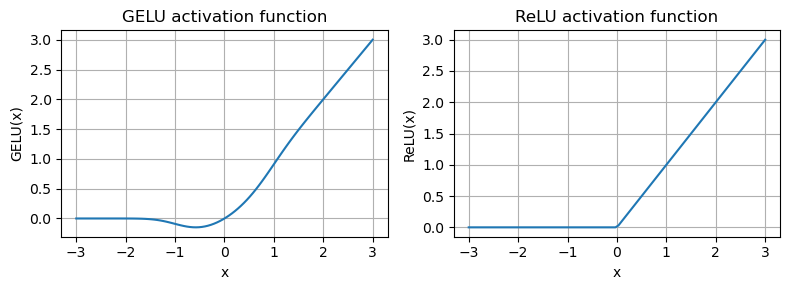

In [29]:
import matplotlib.pyplot as plt
gelu,relu=GElu(),nn.ReLU()

# some sample datat
x=torch.linspace(-3,3,100)
y_gelu,y_relu=gelu(x),relu(x)

plt.figure(figsize=(8,3))
for i, (y,label) in enumerate(zip([y_gelu,y_relu],["GELU", "ReLU"]),1):
    plt.subplot(1,2,i)
    plt.plot(x,y)
    plt.title(f'{label} activation function')
    plt.xlabel('x')

    plt.ylabel(f'{label}(x)')
    plt.grid(True)

plt.tight_layout()
plt.show()

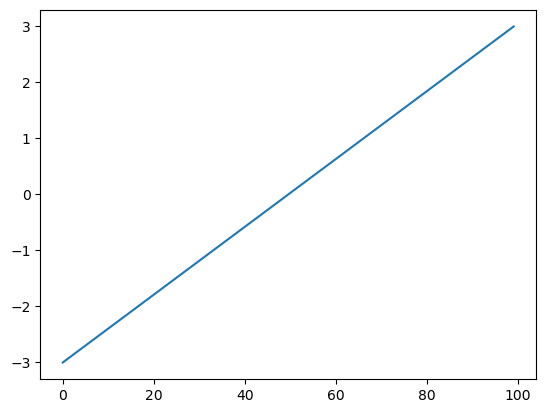

In [30]:
plt.plot(x)

In [31]:
# feddforward neural network
class feedforward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers=nn.Sequential(nn.Linear(cfg['emb_dim'],4*cfg['emb_dim']),
                                 GElu(),
                                 nn.Linear(4*cfg['emb_dim'],cfg['emb_dim']),
                                 )

    def forward(self,x):
        return self.layers(x)
        

In [32]:
print(GPT_CONFIG_124M['emb_dim'])

768


In [33]:
# use gelu actvition function to imlemanet the small neural network module feedforward that we will 

In [34]:
ffn=feedforward(GPT_CONFIG_124M)
x=torch.rand(2,3,768)
out1=ffn(x)
print(out1.shape)

torch.Size([2, 3, 768])


In [35]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

batch1=torch.stack((inputs,inputs),dim=0)
print(batch1.shape)
torch.manual_seed(123)
context_length=batch1.shape[1]
print(context_length)

torch.Size([2, 6, 3])
6


# SHORTCUT CONNECTION

In [36]:
class exapledeepnuralnetwork(nn.Module):
    def __init__(self,layer_size,use_shortcut):
        super().__init__()
        self.use_shortcut=use_shortcut
        self.layers=nn.ModuleList([
            nn.Sequential(nn.Linear(layer_size[0],layer_size[1]),GElu()),
            nn.Sequential(nn.Linear(layer_size[1],layer_size[2],GElu())),
            nn.Sequential(nn.Linear(layer_size[2],layer_size[3])),
            nn.Sequential(nn.Linear(layer_size[3],layer_size[4])),
            nn.Sequential(nn.Linear(layer_size[4],layer_size[5])),
            
            
                         
        ])

    def forward(self,x):
        for layer in self.layers:
            # compute the output of the current layes
            layer_output=layer(x)
            # check if shortcut can be applied
            if self.use_shortcut and x.shape ==layer_output.shape:
                x=x+layer_output
            else:
                x=layer_output
            return x

In [37]:
layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123) # specify random seed for the initial weights for reproducibility
model_without_shortcut = exapledeepnuralnetwork(
layer_sizes, use_shortcut=False
)

In [38]:

def print_gradent(model,x):
    output=model(x)
    target=torch.tensor([[0.]])
    # calculate loss based on how close the tareget and output are
    loss=nn.MSELoss()

    loss=loss(output,target)
    # backward pass to calucate the gradient
    loss.backward()

    for name, parm in model.named_parameters():
        if 'weight' in name :
            print(f"{name} has gradient mean of {parm.grad.abs().mean().item()}")

In [39]:
print_gradent(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.033530622720718384


C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\loss.py:634: UserWarning: Using a target size (torch.Size([1, 1])) that is different to the input size (torch.Size([1, 3])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


AttributeError: 'NoneType' object has no attribute 'abs'

# GPT ARCHITECTURE PART 5: CODING ATTENTION AND LINEAR LAYERS IN A TRANSFORMER BLOCK


In [40]:
class multiheadattention(nn.Module):
    def __init__(self,d_in,d_out,context_length,dropout,num_heads,qkv_bias=False):
        super().__init__()
        assert (d_out%num_heads==0),\
        'd_out must be divisible by num_heads'
        self.d_out=d_out
        self.num_heads=num_heads
        self.head_dim=d_out//num_heads # reduce the production dim to match desired output dim

        self.w_query=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.w_keys=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.w_value=nn.Linear(d_in,d_out,bias=qkv_bias)
        self.dropout=nn.Dropout(dropout)
        self.register_buffer('mask',torch.triu(torch.ones(context_length,context_length),diagonal=1))

    def forward(self,x):
        b,num_tokens,d_in=x.shape

        keys=self.w_keys(x)
        query=self.w_query(x)
        values=self.w_value(x)
        # implicitly split the matrix by adding a 'num_heads' dimention
        # unroll last dim:(b,num_tokens,d_out)-> (b,num_tokrns,num_heads,head_dim)

        keys=keys.view(b,num_tokens,self.num_heads,self.head_dim)
        values=values.view(b,num_tokens,self.num_heads,self.head_dim)
        query=query.view(b,num_tokens,self.num_heads,self.head_dim)

        # transpose: (b,num_tokens,num_heads,head_dim)=(b,num_head,num_tokens,head_dim)
        keys=keys.transpose(1,2)
        values=values.transpose(1,2)
        query=query.transpose(1,2)

        # comuter attention score
        atten_score=query@keys.transpose(2,3)
        # original mask trunced to the number of tokens and convert to bolen
        mased_bool=self.mask.bool()[:num_tokens,:num_tokens]

        # use thr mask to fill attention score
        atten_score.masked_fill(mased_bool,-torch.inf)
        atten_weight=torch.softmax(atten_score/keys.shape[-1]**0.5,dim=-1)
        atten_weight=self.dropout(atten_weight)

        # shape ; (b,num_toenks,num_heads,head_dim)
        contex_vec=(atten_weight@values).transpose(1,2)

        #cobine heads, where self,d_out =self.num_heads*self.head_dim
        contex_vec=contex_vec.contiguous().view(b,num_tokens,self.d_out)
        #contex_vec=self.out_proj(contex_vec)

        return contex_vec

In [41]:

class Transformerblock(nn.ModuleList):
    def __init__(self,cfg):
        super().__init__()
        self.att=multiheadattention(d_in=cfg['emb_dim'],
                                   d_out=cfg['emb_dim'],
                                   context_length=cfg['context_length'],
                                   num_heads=cfg['n_heads'],
                                   dropout=cfg['drop_rate'],
                                   qkv_bias=cfg['qkv_bias'])
        self.ff=feedforward(cfg)
        self.norm1=LayerNorm(cfg['emb_dim'])
        self.norm2=LayerNorm(cfg['emb_dim'])
        self.drop_shortcut=nn.Dropout(cfg['drop_rate'])

    def forward(self,x):
        # shorcut connection for attention block
        shortcut=x
        x=self.norm1(x)
        x=self.att(x) # shape [batch_size,num_tokrns,emd_dim]
        x=self.drop_shortcut(x)
        x=x+shortcut  # add the original input blocks

        # now shortcut connection for feed forward  block
        shortcut=x
        x=self.norm2(x) # this is called pre-normalization
        x=self.ff(x)
        x=self.drop_shortcut(x)
        x=x+shortcut  # ADD THE ORIGINAL INPUT BACK


        return x

In [42]:
# TEST THIS TRANSFORMER BLOCK
torch.manual_seed(123)
x=torch.rand(2,4,768)
block=Transformerblock(GPT_CONFIG_124M)
output=block(x)
print(output.shape)
output

torch.Size([2, 4, 768])


tensor([[[ 0.6232,  0.8351, -0.2264,  ...,  0.9450,  1.1221,  0.5007],
         [ 0.5622,  0.6722, -0.0833,  ...,  0.5042,  0.2383,  1.0384],
         [ 0.7449,  0.9200,  0.4111,  ...,  0.8529,  0.6230,  0.5963],
         [ 0.0947,  0.8582,  1.0144,  ...,  0.3840,  0.6042,  0.7172]],

        [[ 0.4043,  1.0353,  1.0099,  ...,  0.0744,  0.3674,  0.5606],
         [ 0.0549,  0.1537,  0.8253,  ...,  0.8527,  0.6806,  0.4514],
         [ 0.5913,  0.5378,  0.0195,  ...,  0.7868,  0.5859,  0.2875],
         [ 0.4841,  0.6041,  0.0342,  ...,  1.2291,  0.7183,  0.2364]]],
       grad_fn=<AddBackward0>)

In [43]:
#GPT_CONFIG_124MM
# SEE THAT INPUT SHAPE SAME AS OUTPUT SHAPE THE TRANSFRMER BLOCK MATIANS THE INPUT DIMENSTION IN ITS OUTPUT
# INDICATING TAHAT THE TRANSFORMER ARCIECTURE PROCESS SEQUENCE OF DATAT WITHOUT ALTERNATING THEIER SHAPE THROUGHT THE NETWORK
GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_length': 1024,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

# GPT ARCHITECTURE PART6: ENTIRE GPT MODEL ARCHITECTURE IMPLEMENTATION

In [44]:
class GPTModel(nn.ModuleList):
    def __init__(self,cfg):
        super().__init__()
        self.tok_emb=nn.Embedding(cfg['vocab_size'],cfg['emb_dim'])
        self.pos_emb=nn.Embedding(cfg['context_length'],cfg['emb_dim'])
        self.drop_emb=nn.Dropout(cfg['drop_rate'])

        self.trf_blocks=nn.Sequential(
            *[Transformerblock(cfg) for _ in range(cfg['n_layers'])])

        self.final_norm=LayerNorm(cfg['emb_dim'])
        self.out_head=nn.Linear(cfg['emb_dim'],cfg['vocab_size'],bias=False)
        

    def forward(self,in_idx):
        batch_size,seq_length=in_idx.shape
        tok_embbeds=self.tok_emb(in_idx)

        pos_embeds=self.pos_emb(torch.arange(seq_length))
        x=tok_embbeds+pos_embeds
        x=self.drop_emb(x)
        x=self.trf_blocks(x)
        x=self.final_norm(x)
        logits=self.out_head(x)
        return logits

### lets intialize the 124 million parameter GPT model using the GPT_CINFIG_124M dict.

In [45]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
out=model(batch)
print('input batch',batch)

print('output shape:', out.shape)

print(out)

input batch tensor([[15745,  6942, 19523,   481],
        [15745,  2163, 18305,   261]])
output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.5140,  0.4102,  0.6752,  ..., -0.2007, -0.5794,  0.3961],
         [ 0.0599,  0.3178, -0.7328,  ..., -0.3066,  0.8446, -0.2002],
         [ 0.4317,  0.6483, -0.5038,  ..., -0.5331,  0.1037,  0.4013],
         [ 0.4098,  0.6043,  0.0074,  ..., -0.7349,  0.1091,  0.3649]],

        [[ 0.7810,  0.6859,  0.4551,  ..., -0.4810,  0.5005, -0.0047],
         [-0.4884,  0.1571, -0.1113,  ..., -0.1180,  1.0903, -0.4502],
         [ 0.3732,  1.5971,  0.1139,  ..., -0.0412, -0.2093,  0.9043],
         [-0.1269,  1.8516, -0.0606,  ..., -0.1705, -0.3999,  0.3481]]],
       grad_fn=<UnsafeViewBackward0>)


In [46]:
# using the nuel() method short for number of elements.collact tiltal number of paramerts
# tensors
total_parms=sum(p.numel() for p in model.parameters())
print(f'total number of parameters: {total_parms}')

total number of parameters: 155922432


In [47]:
# this is because tying
total_parms_gpt2=total_parms-sum(p.numel() for p in model.out_head.parameters())
print('number of trainble parameters considring weight tying:',total_parms_gpt2)

number of trainble parameters considring weight tying: 117325056


In [48]:
total_size_byte=total_parms*4
total_size_mb=total_size_byte/(1024*1024)
print(f'tota size of the model:{total_size_mb:.2f} MB')

tota size of the model:594.80 MB


# GPT ARCHITECURE PART 7: GENRATING TEXT FROM OUTPUT TOKENS


In [49]:
def genrate_text_sample(model,idx,max_new_tokens,context_size):

    for _ in range(max_new_tokens):

        #crop current contetx if it exceed the supporded context size
        # eg. if llm support only 5 tokens and the context size is 10 
        # then only the last 5 tokens are used as context
        idx_cond=idx[:,-context_size:]

        # get the prediction
        with torch.no_grad():
            logits=model(idx_cond)
            # focus only on the last time step
            # (batch,n_token,vocab_size) become (batch,vocab_size)
            
            logits=logits[:,-1,:]

            # apply the softmax to get probabilty
            probs=torch.softmax(logits,dim=-1)
            # get the idx of the vocab entery with the higest probablity value
            idx_next=torch.argmax(probs,dim=-1,keepdim=True)
            # append sampled index to the runing sequence
            idx=torch.cat((idx, idx_next),dim=-1) #(batch,n_tokens+1)

    return  idx

In [50]:
# we encode the input context into token ids
start_context='Hello, I am '
encode=tokenizer.encode(start_context)
print('encoded:',encode)

encoded_tensor=torch.tensor(encode).unsqueeze(0)
print('emcoder_tensor.shape:',encoded_tensor.shape)

encoded: [13225, 11, 357, 939, 220]
emcoder_tensor.shape: torch.Size([1, 5])


In [51]:
model.eval()
out=genrate_text_sample(model=model,idx=encoded_tensor,max_new_tokens=6,context_size=GPT_CONFIG_124M['context_length'])
print('output:',out)
print('output length:',len(out[0]))


output: tensor([[13225,    11,   357,   939,   220, 48006, 43751, 15741, 39607,  6043,
          5502]])
output length: 11


In [52]:
encoded_tensor

tensor([[13225,    11,   357,   939,   220]])

In [53]:
# now using the decode method of the tokenizer convert the token ids to  text
decode_text=tokenizer.decode(out.squeeze(0).tolist())
print(decode_text)

Hello, I am ហ685TT eftirudi applic


In [54]:
print(tokenizer.encode('ravi kumar'))

[81, 7183, 14289, 277]


# use GPT TO GENRATE TEXT

In [55]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

In [56]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.eval(); #  disable droput during infrences


In [57]:
import tiktoken
def text_to_token_ids(text,tokenizer):
    encode=tokenizer.encode(text,allowed_special={'<|endoftext|>'})
    encode_tensor=torch.tensor(encode).unsqueeze(0)

    return encode_tensor

def token_id_to_text(token_id,tokenizer):
    flate=token_id.squeeze(0) # remove batvh dimention
    return tokenizer.decode(flate.tolist())
start_context='Every effort moves you??'
tokenizer=tiktoken.get_encoding('gpt2')

token_ids=genrate_text_sample(model=model,
                             idx=text_to_token_ids(start_context,tokenizer=tokenizer),
                             max_new_tokens=10,
                             context_size=GPT_CONFIG_124M['context_length'])

print('output text:\n',token_id_to_text(token_ids,tokenizer))
    

output text:
 Every effort moves you?? drawsNevSpecforcingmaleOften staggerperia Character chasing


# calculating the text genration loss: cross entropy and perplexity

In [58]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107,  588, 11311]]) #  " really like chocolate"]

fedding the inputs to the model that returns logits vector for the 2 inputs exaplme each have 23 tokens
each tokens is a 50257-dimention embedding vector crosponding to the size of vocabulary
applying the softmax function to logits tensor that gives tensor of the same dimetion that has probality
score

In [60]:
with torch.no_grad():
    logits=model(inputs)
    probs=torch.softmax(logits,dim=-1)
    print(probs)
    print(probs.shape) # (batch,num_tokens,vocac_size)

tensor([[[1.3622e-05, 2.3144e-05, 1.2963e-05,  ..., 1.4032e-05,
          1.6544e-05, 2.9123e-05],
         [8.3910e-06, 3.7674e-05, 6.2350e-06,  ..., 1.4282e-05,
          9.4147e-06, 1.3549e-05],
         [1.1789e-05, 2.1045e-05, 2.9535e-05,  ..., 1.1310e-05,
          7.9363e-06, 2.2653e-05]],

        [[1.3963e-05, 3.0514e-05, 1.3497e-05,  ..., 1.8047e-05,
          2.7544e-05, 1.0366e-05],
         [9.8070e-06, 2.4050e-05, 8.5552e-06,  ..., 1.3776e-05,
          1.6998e-05, 1.6910e-05],
         [1.4481e-05, 2.3502e-05, 2.0547e-05,  ..., 1.3343e-05,
          9.4308e-06, 1.8514e-05]]])
torch.Size([2, 3, 50257])


In [61]:
print(torch.argmax(probs,dim=-1,keepdim=True))

tensor([[[19663],
         [25000],
         [22748]],

        [[19663],
         [ 4054],
         [ 1923]]])


In [62]:
# this is because the model is not train yet
logits

tensor([[[-0.2071,  0.3229, -0.2567,  ..., -0.1775, -0.0128,  0.5527],
         [-0.6963,  0.8055, -0.9933,  ..., -0.1645, -0.5812, -0.2172],
         [-0.3553,  0.2242,  0.5631,  ..., -0.3967, -0.7510,  0.2978]],

        [[-0.1902,  0.5915, -0.2242,  ...,  0.0663,  0.4891, -0.4881],
         [-0.5377,  0.3594, -0.6742,  ..., -0.1978,  0.0123,  0.0071],
         [-0.1530,  0.3312,  0.1969,  ..., -0.2349, -0.5819,  0.0927]]])

In [63]:
q=targets[1]
q

tensor([ 1107,   588, 11311])

In [64]:
print(f'taget batch 1: {token_id_to_text(targets[0],tokenizer)}')
print(f'output_batch 1: {token_id_to_text(token_ids[0].flatten(),tokenizer)}')

taget batch 1:  effort moves you
output_batch 1: Every effort moves you?? drawsNevSpecforcingmaleOften staggerperia Character chasing


# cross-entropy loss


In [65]:
text_idx=0
target_prob_1=probs[text_idx,[0,1,2],targets[text_idx]]
print('text 1: ',target_prob_1)

text_idx=1
target_prob_2=probs[text_idx,[0,1,2],targets[text_idx]]
print('text 2: ',target_prob_2)

text 1:  tensor([1.7834e-05, 3.2708e-05, 5.9516e-05])
text 2:  tensor([1.2410e-05, 3.9356e-05, 2.8014e-05])


In [66]:
log_probas=torch.log(torch.cat((target_prob_1,target_prob_2)))
print(log_probas)

tensor([-10.9344, -10.3279,  -9.7293, -11.2970, -10.1429, -10.4828])


In [67]:
# calcualte tha avrage probabilty for each tokens
avg_log_probs=torch.mean(log_probas)
print(avg_log_probs)

tensor(-10.4857)


In [68]:
# the goal is maximize the avg log probs as larger as possible by optimizing the model weights
# the value negative of -10.4857 i.e 10.4857 called cross entropy loss in deep learning

neg_avg_log_prob=avg_log_probs*-1
print(neg_avg_log_prob)

tensor(10.4857)


In [69]:
# logits have shape (batch,num_tokens,vocab_size)
print('logits.shape:',logits.shape)
print('taget.shape:',targets.shape) # (batch_size,num_tokens)

logits.shape: torch.Size([2, 3, 50257])
taget.shape: torch.Size([2, 3])


In [70]:
# for cross entropy need to flate the logits and tagets
logits_flate=logits.flatten(0,1)
targets_flate=targets.flatten()

print("Flattened logits:", logits_flate.shape)
print("Flattened targets:", targets_flate.shape)


Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [71]:
loss=torch.nn.functional.cross_entropy(logits_flate,targets_flate)
print(loss)

tensor(10.4857)


In [72]:
# perplexity it is simaply the exponatial of the cross entropy loss

In [73]:
perplexity=torch.exp(loss)
print(perplexity)

tensor(35799.9766)


# calculating the trainging and validation loss

In [74]:
import os
import urllib.request
file_path=r"C:\Users\PC\Downloads\the-verdict.txt"
with open(file_path,'r',encoding='utf-8') as file:
    row_text=file.read()

In [75]:
row_text[:99]

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no '

In [76]:
import tiktoken
tokenizer=tiktoken.get_encoding('gpt2')
total_charectors=len(row_text)
total_tokens=len(tokenizer.encode(row_text))
print('cheractors:',total_charectors)

print('tokens:',total_tokens)

cheractors: 20557
tokens: 5165


# implementing the Dataloader:

In [77]:
from torch.utils.data import Dataset,DataLoader
class gptdataset(Dataset):
    def __init__(self,txt,tokenizer,max_length,stride):
        self.input_ids=[]
        self.target_ids=[]

        # tokenize the entrie text
        token_ids=tokenizer.encode(txt,allowed_special={'<|endoftext|>'})

        ## Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0,len(token_ids)-max_length,stride):
            input_chunk=token_ids[i:i + max_length]
            target_chunk=token_ids[i+1:i+max_length+1]

            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
    def __len__(self):
        return len(self.input_ids)
    def __getitem__(self,idx):
        return self.input_ids[idx],self.target_ids[idx]


def create_dataloader(txt,batch_size=4,max_length=256,stride=128,shuffle=True,drop_last=True,
                     num_workers=0):
    # ininalize the tokeniwer
    tokennizer=tiktoken.get_encoding('gpt2')

    # create datatset
    dataset=gptdataset(txt,tokennizer,max_length,stride)

    # create dtatloaders
    dataloader=DataLoader(dataset,batch_size,shuffle=True,drop_last=drop_last,num_workers=num_workers)

    return dataloader
        

        

In [78]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

In [ ]:
def create_dataloader(text,batch_size=4,max_length=256,strid=128,shufle=True,num_worker=0):
    tokenizer=tiktoken.get_encoding('gpt2')

    dataset=gptdataset(text,tokenizer,max_length,strid)

    dataloader=DataLoader(dataset,batch_size,drop_last=True,num_workers=num_workers)

    return dataloader

In [79]:
# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(row_text))
train_data = row_text[:split_idx]
val_data = row_text[split_idx:]


In [81]:
torch.manual_seed(123)
train_loader=create_dataloader(train_data,
                              batch_size=2,max_length=GPT_CONFIG_124M['context_length'],
                              stride=GPT_CONFIG_124M['context_length'],drop_last=True,
                              shuffle=True,
                              num_workers=0)

val_loader=create_dataloader(val_data,batch_size=2,
                            max_length=GPT_CONFIG_124M['context_length'],stride=GPT_CONFIG_124M['context_length'],
                            drop_last=False,
                            shuffle=True,num_workers=0)


In [82]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

print(len(train_loader))
print(len(val_loader))


Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])
9
1


In [83]:
train_tokens = 0
for input_batch, target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens = 0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:", train_tokens)
print("Validation tokens:", val_tokens)
print("All tokens:", train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


In [84]:
def cal_loss_batch(input_batch,targrt_batch,model):
   # input_batch,target_batch=in
    logits=model(input_batch)
    loss=torch.nn.functional.cross_entropy(logits.flatten(0,1),targrt_batch.flatten())

    return loss

In [85]:

def cal_loss_loader(data_loader,model,num_batches=None):
    total_loss=0
    if len(data_loader)==0:
        return float('nan')
    elif num_batches is None:
        num_batches=len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i,(input_batch,target_batch) in enumerate(data_loader):
        if i< num_batches:
            loss=cal_loss_batch(input_batch,target_batch,model)
            total_loss+=loss.item()
        else:
            break

        return total_loss/num_batches
        
        

# TRAING LOOP FOR THE LLM 

In [86]:
def train_model_simple(model, train_loader, val_loader, optimizer, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = cal_loss_batch(input_batch, target_batch, model)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel() # Returns the total number of elements (or tokens) in the input_batch.
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0: 
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader,  eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, start_context
        )

    return train_losses, val_losses, track_tokens_seen

In [87]:
def evaluate_model(model, train_loader, val_loader,  eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = cal_loss_loader(train_loader, model, num_batches=eval_iter)
        val_loss = cal_loss_loader(val_loader, model, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [88]:
def generate_and_print_sample(model, tokenizer, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer)
    with torch.no_grad():
        token_ids = genrate_text_sample(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_id_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [77]:
import time
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, 
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 1.996, Val loss 10.040
Ep 1 (Step 000005): Train loss 1.630, Val loss 8.341
Every effort moves you, the, the the,, the the, the, the the, the, the, the, the the, the, the, the, the, the, the, the, the, the,, the, the, the, the
Ep 2 (Step 000010): Train loss 1.311, Val loss 7.132
Ep 2 (Step 000015): Train loss 1.200, Val loss 6.633
Every effort moves you.                                                 
Ep 3 (Step 000020): Train loss 1.174, Val loss 6.481
Ep 3 (Step 000025): Train loss 1.071, Val loss 6.529
Every effort moves you, the was, and the, the the-- the of the the. ", the-- of the, the of the the the of the the, the the the of the the-- the. of the, the of the-- of the the
Ep 4 (Step 000030): Train loss 1.092, Val loss 6.453
Ep 4 (Step 000035): Train loss 0.996, Val loss 6.318
Every effort moves you of the " had the " of the " had the " of the " of the " had to me, the "                          
Ep 5 (Step 000040): Train loss 0.953, Val loss 6.18

# DECODING STRATRGIES TO CONTROL RANDOMNESS

In [89]:
model.eval()

GPTModel(
  (0): Embedding(50257, 768)
  (1): Embedding(256, 768)
  (2): Dropout(p=0.1, inplace=False)
  (3): Sequential(
    (0): Transformerblock(
      (0): multiheadattention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_keys): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (1): feedforward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GElu()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (2-3): 2 x LayerNorm()
      (4): Dropout(p=0.1, inplace=False)
    )
    (1): Transformerblock(
      (0): multiheadattention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_keys): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_featu

In [90]:
# plug the gt model instance into the genrated_text_sample function which use  llm to genrate one token at a time
tokenizer=tiktoken.get_encoding('gpt2')
token_id=genrate_text_sample(model=model,idx=text_to_token_ids('Every efforts',tokenizer),
                            max_new_tokens=25,
                            context_size=GPT_CONFIG_124M['context_length'])

print('output text:\n',token_id_to_text(token_id,tokenizer))

output text:
 Every effortsafi大 prepared Kardashdal antidepressant Enemy KEY625ror uncomfortable2017 Dirk heightened friquez import Gall warm vehement Don ¯stud took12


In [91]:
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = genrate_text_sample(
    model=model,
    idx=text_to_token_ids("Every effort moves you was", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_id_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you was reinvent vital lab Production POLITICO Westbrook recorder Gravity mentors Rules hiveavageeele Saur quieter editions� Tamil integer holding Apr Colossus vantageBl engulf


In [92]:
inverse_vocab={v:k for k , v in vocab.items()}
# aasume the llm is given the start context 'every efforts moves you ' and genrates the following neext 
# token logits
next_token_logits=torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])


NameError: name 'vocab' is not defined

In [ ]:
probs=torch.softmax(next_token_logits,dim=0)
netx_token_id=torch.argmax(probs).item()
print(inverse_vocab.get(netx_token_id))

In [ ]:
probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()
print(inverse_vocab[next_token_id])

In [ ]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8
} 

In [93]:
inverse_vocab={v:k for v, k in vocab.items()}


NameError: name 'vocab' is not defined

In [94]:
next_token_logits=torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])


In [95]:
probs=torch.softmax(next_token_logits,dim=0)
next_token_id=torch.argmax(probs).item()


In [96]:
print(inverse_vocab[next_token_id])

NameError: name 'inverse_vocab' is not defined

In [97]:
# to implement a probabilty sampling process we can noe replace the argmax with multinomail function
# function in pytorch
torch.manual_seed(123)
next_token_id=torch.multinomial(probs,num_samples=1).item()
print(inverse_vocab[next_token_id])

NameError: name 'inverse_vocab' is not defined

In [98]:
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample=[torch.multinomial(probas,num_samples=1).item() for i in range(1,100)]
    sample_ids=torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sample_ids):
        if freq==0:
            continue
        print(f'{freq} x {inverse_vocab[i]}')

print_sampled_tokens(probs)

NameError: name 'inverse_vocab' is not defined

In [99]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

In [100]:
print(scaled_probas)

[tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03]), tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22]), tensor([0.1546, 0.0750, 0.0429, 0.2421, 0.0869, 0.0454, 0.0430, 0.2203, 0.0898])]


# decording strategey 2: TOP-K SAMPLING

In [101]:
import torch
top_k=3
next_token_logits=torch.tensor([4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79])
top_logits,top_pos=torch.topk(next_token_logits,top_k)
print('TOp logits:',top_logits)
print('top possition:',top_pos)

TOp logits: tensor([6.7500, 6.2800, 4.5100])
top possition: tensor([3, 7, 0])


In [102]:
# we apply pytorch's where function to set th logits  values of tokens that  are below the lowest b
# logits value within our top 3 secatiom to negative infinity
new_logits=torch.where(
    condition=next_token_logits<top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits)
print(next_token_logits)

tensor([ 4.5100,  0.8900, -1.9000,  6.7500,  1.6300, -1.6200, -1.8900,  6.2800,
         1.7900])


In [103]:
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [104]:
# let apply the softmax function to turn these into next-token probility
topk_prob=torch.softmax(new_logits,dim=0)
topk_prob

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])

In [105]:
def generate(model,idx,max_new_token,context_size,temprature=0.0,top_k=None,eos_id=None):
    for _ in range(max_new_token):
        idx_cond=idx[:,-context_size:]
        with torch.no_grad():
            logits=model(idx_cond)
            logits=logits[:,-1,:]

        # filter filter logits with top_k sampling
        if top_k is not None:
            # keep only top_k values
            top_logits,_=torch.topk(logits,top_k,dim=-1)
            #min_val=top_logits[:,-1]
            
            logits=torch.where(logits<top_logits[:,-1],torch.tensor(float('-inf')),logits)

        # apply temprature scaling
        if temprature>0.0:
            logits=logits/temprature

            # apply softmax to get probability
            probs=torch.softmax(logits,dim=-1)
            # sapmle from the distribution
            idx_next=torch.multinomial(probs,num_samples=1)
        else:
            idx_next=torch.argmax(logits,dim=-1,keepdim=True)

        if idx_next==eos_id:
            break

            # append sampled index to the runing sequence
            idx=torch.cat((idx,idx_next),dim=1)
    return idx
            
        

In [106]:
GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_length': 256,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'qkv_bias': False}

In [107]:
def generate(model, idx, max_new_token, context_size, temprature=0.0, top_k=None, eos_id=None):
    for _ in range(max_new_token):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
            logits = logits[:, -1, :]

        # filter logits with top_k sampling
        if top_k is not None:
            # keep only top_k values
            top_logits, _ = torch.topk(logits, top_k, dim=-1)
            
            # (Note: Using keepdim=True or slicing like [-1:] prevents dimension errors)
            logits = torch.where(logits < top_logits[:, -1:], torch.tensor(float('-inf')), logits)

        # apply temprature scaling
        if temprature > 0.0:
            logits = logits / temprature

            # apply softmax to get probability
            probs = torch.softmax(logits, dim=-1)
            # sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if idx_next == eos_id:
            break

        # YAHAN THEEK KIYA HAI: Indentation ko 'if' ke bahar kar diya hai
        # append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)
        
    return idx

In [108]:
torch.manual_seed(123)
token_id=generate(model=model,temprature=0.5,idx=text_to_token_ids('i love you ',tokenizer),max_new_token=10,context_size=GPT_CONFIG_124M['context_length'],top_k=25,eos_id=2)

In [109]:
print(token_id_to_text(token_id=token_id,tokenizer=tokenizer))

i love you  willingly BAD Jets catalog undergone trillion poppingorman respectable meas


In [110]:
#model =GPTModel(GPT_CONFIG_124M)
#torch.save(model.sta)

In [111]:
text_to_token_ids('Every??',tokenizer)
print(token_id_to_text(token_id,tokenizer))

i love you  willingly BAD Jets catalog undergone trillion poppingorman respectable meas


In [112]:
token_ids = generate(
    model=model,
    idx=text_to_token_ids("Heloo my name is ravi ", tokenizer),
    max_new_token=20,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=10,
    temprature=0.4
)

print("Output text:\n", token_id_to_text(token_ids, tokenizer))

print(len(row_text))

Output text:
 Heloo my name is ravi  tuned upsetting escal ens CRlaw Alvkai sell FCC Spiritsätem YOUR separatevertising wording vocalsUSER IBM
20557


# loadeing anf saving  Model weights in pytorch

In [113]:
model=GPTModel(GPT_CONFIG_124M)
torch.save(model.state_dict(),'model.pth')


In [114]:
model=GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load('model.pth'))
model.eval()

GPTModel(
  (0): Embedding(50257, 768)
  (1): Embedding(256, 768)
  (2): Dropout(p=0.1, inplace=False)
  (3): Sequential(
    (0): Transformerblock(
      (0): multiheadattention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_keys): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (1): feedforward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GElu()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (2-3): 2 x LayerNorm()
      (4): Dropout(p=0.1, inplace=False)
    )
    (1): Transformerblock(
      (0): multiheadattention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_keys): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_featu

In [115]:
parea=sum(p.numel() for p in model.parameters())
parea

155332608

In [116]:
optimizer=torch.optim.AdamW(model.parameters(),lr=0.0004,weight_decay=0.1)

torch.save({
    'modelo_satate_dict':model.state_dict(),
    'optimizer_state_dict':optimizer.state_dict(),
    
},
     'model_amd_optimizer.path')

In [117]:
chekpoint=torch.load('model_amd_optimizer.path')
model=GPTModel(GPT_CONFIG_124M)
model.load_state_dict(chekpoint['modelo_satate_dict'])
optimizer=torch.optim.AdamW(model.parameters(),lr=5e-4,weight_decay=0.1)
optimizer.load_state_dict(chekpoint['optimizer_state_dict'])

model.train();

# FINETUNING FOR CLASSIFICATION

In [118]:
import pandas as pd
import numpy as np
import zipfile
import os
from pathlib import Path

In [182]:
df=pd.read_csv(r"C:\Users\PC\Downloads\sms+spam+collection.zip",sep='\t',header=None,names=['Label','Text'])
df

ValueError: Multiple files found in ZIP file. Only one file per ZIP: ['SMSSpamCollection', 'readme']

In [119]:
with   zipfile.ZipFile(r'C:\Users\PC\Downloads\sms+spam+collection.zip','r') as dataframe:
     print(dataframe.namelist())

     with dataframe.open('SMSSpamCollection') as f :
        df=pd.read_csv(f,
                      sep='\t',
                      header=None,
                      names=['labels','text'])



['SMSSpamCollection', 'readme']


In [120]:
print(df.head(9))

  labels                                               text
0    ham  Go until jurong point, crazy.. Available only ...
1    ham                      Ok lar... Joking wif u oni...
2   spam  Free entry in 2 a wkly comp to win FA Cup fina...
3    ham  U dun say so early hor... U c already then say...
4    ham  Nah I don't think he goes to usf, he lives aro...
5   spam  FreeMsg Hey there darling it's been 3 week's n...
6    ham  Even my brother is not like to speak with me. ...
7    ham  As per your request 'Melle Melle (Oru Minnamin...
8   spam  WINNER!! As a valued network customer you have...


In [121]:
df.value_counts('labels')

labels
ham     4825
spam     747
Name: count, dtype: int64

In [122]:
# blaced data d=swet for finetuing
def crate_blanced_dataset(df):

    # count the instances of  spam
    num_spam=df[df['labels']=='spam'].shape[0]
    print(num_spam)

    #randomly saple the ham instance to match  the nuber of of  spam instance
    ham_subset=df[df['labels']=='ham'].sample(num_spam,random_state=123)

    # cmine ham with spam 
    blanced_df=pd.concat([ham_subset,df[df['labels']=='spam']])

    return blanced_df

blanced_df=crate_blanced_dataset(df)
print(blanced_df.value_counts('labels'))
print(blanced_df.head())

747
labels
ham     747
spam    747
Name: count, dtype: int64
     labels                                               text
4307    ham  Awww dat is sweet! We can think of something t...
4138    ham                             Just got to  &lt;#&gt;
4831    ham  The word "Checkmate" in chess comes from the P...
4461    ham  This is wishing you a great day. Moji told me ...
5440    ham      Thank you. do you generally date the brothas?


In [220]:
fro  simlicity and bex=cause of weperfrem a small dataset 

SyntaxError: invalid syntax (2611960673.py, line 1)

In [123]:
blanced_df["labels"] = blanced_df["labels"].map({"ham": 0, "spam": 1})

In [124]:
def random_split(df,train_frac,validation_frac):

    df =df.sample(frac=1,random_state=123).reset_index(drop=True)

    # calculatesplit indicees
    train_end=int(len(df)*train_frac)
    validation_end=train_end+int(len(df)*validation_frac)

    # split thed datatframe 
    train_df=df[:train_end]
    validation_df=df[train_end:validation_end]
    test_df=df[validation_df:]

    return train_df,validation_df,test_df
    

In [125]:
train_df,validation_df,test_df=random_split(blanced_df,train_frac=0.7,validation_frac=0.1)


TypeError: cannot do slice indexing on RangeIndex with these indexers [      labels                                               text
1045       1  Mila, age23, blonde, new in UK. I look sex wit...
1046       1  Hungry gay guys feeling hungry and up 4 it, no...
1047       0  Ugh. Gotta drive back to sd from la. My butt i...
1048       0  Please leave this topic..sorry for telling that..
1049       1  We tried to contact you re our offer of New Vi...
...      ...                                                ...
1189       0  Hey gorgeous man. My work mobile number is. Ha...
1190       0                         Just sleeping..and surfing
1191       0           I'm in solihull, | do you want anything?
1192       0                       Jay told me already, will do
1193       1  U can WIN £100 of Music Gift Vouchers every we...

[149 rows x 2 columns]] of type DataFrame

In [126]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(blanced_df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder


In [127]:
print(len(train_df))
print(len(validation_df))
print(len(test_df))

1045
149
300


In [230]:
# now save the datat as csv
train_df.to_csv('train.csv',index=None)
validation_df.to_csv('validation.csv',index=None)
test_df.to_csv('test.csv',index=None)

In [1]:
from transformers import GPT2LMHeadModel
CHOOSE_MODEL = "GPT-2 Small (gpt2)"
model_name = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")
print(f"Loading {model_name} weights from Hugging Face...")
model = GPT2LMHeadModel.from_pretrained(model_name)
model.eval()


Loading gpt2 weights from Hugging Face...


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

C:\Users\PC\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\PC\.cache\huggingface\hub\models--gpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

# fintunog for clssigiction

In [129]:
tota_param=sum(p.numel() for p in model.parameters())
print(tota_param)

155332608


In [204]:
import torch
from torch.utils.data import DataLoader,Dataset

class sapledataset(Dataset):
    def __init__(self,csv_file,tokenizer,max_length=None,pad_token_id=50256):
        self.data=pd.read_csv(csv_file)
        # pretokenized text

        self.encoded_texts=[tokenizer.encode(text) for text in self.data['text']]

        if max_length is None:
            self.max_length=self._longest_encoded_length()

        else:
            self.max_length=max_length
            # truncat seqewence if there are longer than max_length
            self.encoded_texts= [encoded_text[:self.max_length]  for encoded_text in self.encoded_texts]

        # pad seqence to the longest seqence
        self.encoded_texts =[encoded_text+[pad_token_id]*(self.max_length-len(encoded_text)) for  encoded_text in self.encoded_texts]

    def __getitem__(self,index):
        encoded=self.encoded_texts[index]  
        label=self.data.iloc[index]['labels']
        return(torch.tensor(encoded,dtype=torch.long),
              torch.tensor(label,dtype=torch.long))

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length=0
        for encoded_text  in self.encoded_texts:
            encode_length=len(encoded_text)
            if encode_length> max_length:
                max_length=encode_length

        return max_length
  

In [209]:
train_dataset=sapledataset(csv_file='train.csv',
                          max_length=None,
                          tokenizer=tokenizer,
                          pad_token_id=50256)
print(train_dataset.max_length)
print(val_dataset.max_length)

print(test_dataset.max_length)

120
120
120


In [208]:
val_dataset=sapledataset(csv_file='validation.csv',max_length=train_dataset.max_length,
                        tokenizer=tokenizer)
test_dataset=sapledataset(csv_file='test.csv',max_length=train_dataset.max_length,tokenizer=tokenizer)

In [212]:
# now create train_loader ,test_loader,val_loader for training
from torch.utils.data import DataLoader
torch.manual_seed(123)
train_loader=DataLoader(dataset=train_dataset,batch_size=8,shuffle=True,num_workers=0,drop_last=True)
valdation_loader=DataLoader(dataset=val_dataset,batch_size=8,num_workers=0,drop_last=False)
test_loader=DataLoader(dataset=test_dataset,batch_size=8,num_workers=0,drop_last=False)



In [213]:
for input_batch, target_batch in train_loader:
    pass
print(input_batch.shape)

torch.Size([8, 120])


1

In [130]:
for parms in model.parameters():
    parms.requires_grad=False

In [131]:
BASE_CONFIG = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

In [159]:
import torch
torch.manual_seed(123)
num_xlass=2
#model.lm_head=torch.nn.Linear(in_features=768,out_features=num_xlass)
model.out_head=torch.nn.Linear(in_features=768,out_features=2)
print(model)

GPTModel(
  (0): Embedding(50257, 768)
  (1): Embedding(256, 768)
  (2): Dropout(p=0.1, inplace=False)
  (3): Sequential(
    (0): Transformerblock(
      (0): multiheadattention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_keys): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (1): feedforward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GElu()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (2-3): 2 x LayerNorm()
      (4): Dropout(p=0.1, inplace=False)
    )
    (1): Transformerblock(
      (0): multiheadattention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_keys): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_featu

In [160]:
#print(model)
model.out_head=torch.nn.Linear(in_features=768,out_features=2)
print(model)

GPTModel(
  (0): Embedding(50257, 768)
  (1): Embedding(256, 768)
  (2): Dropout(p=0.1, inplace=False)
  (3): Sequential(
    (0): Transformerblock(
      (0): multiheadattention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_keys): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (1): feedforward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GElu()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (2-3): 2 x LayerNorm()
      (4): Dropout(p=0.1, inplace=False)
    )
    (1): Transformerblock(
      (0): multiheadattention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_keys): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_featu

In [161]:
for parm in model.trf_blocks[-1].parameters():
    parm.requires_grad=True

for parm in model.final_norm.parameters():
    parm.requires_grade=True

In [162]:
inputs=tokenizer.encode('Do you have time')
inputs=torch.tensor(inputs).unsqueeze(0)
print('INputs:',inputs)
print('input dimentiond: ',inputs.shape)

INputs: tensor([[5211,  345,  423,  640]])
input dimentiond:  torch.Size([1, 4])


In [163]:
#print(torch.softmax(output,dim=-1))
model

GPTModel(
  (0): Embedding(50257, 768)
  (1): Embedding(256, 768)
  (2): Dropout(p=0.1, inplace=False)
  (3): Sequential(
    (0): Transformerblock(
      (0): multiheadattention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_keys): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_features=768, out_features=768, bias=False)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (1): feedforward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GElu()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (2-3): 2 x LayerNorm()
      (4): Dropout(p=0.1, inplace=False)
    )
    (1): Transformerblock(
      (0): multiheadattention(
        (w_query): Linear(in_features=768, out_features=768, bias=False)
        (w_keys): Linear(in_features=768, out_features=768, bias=False)
        (w_value): Linear(in_featu

In [167]:
# pass encoded token id to model as usual
with torch.no_grad():
    output=model(inputs)
print('outputs:\n', output)
print('output dimention:',output.shape)

outputs:
 tensor([[[-1.0037, -0.2960],
         [ 0.5170,  0.5936],
         [ 0.0385,  0.4215],
         [-0.3629, -0.5561]]])
output dimention: torch.Size([1, 4, 2])


In [168]:
print('Last output token:',output[:,-1,:])

Last output token: tensor([[-0.3629, -0.5561]])


# CALCULATING THE CLASSIFICATION LOSS AND ACCURACY

In [177]:
# let consider the last token from the previous sectionn:
print('last output token :', output[:,-2,:])

last output token : tensor([[0.0385, 0.4215]])


In [184]:
# obtain the class label ;
probas=torch.softmax(output[:,-1,:],dim=-1)
label=torch.argmax(probas)
print('class label: ',label.item())

class label:  0


In [186]:
logits=output[:,-1,:]
label=torch.argmax(logits)
print('class label:', label.item())

class label: 0


In [191]:
def calc_acuuracy_loader(data_loader,model,num_batches=None):
    model.eval()
    correct_prediction,num_examples=0,0

    if num_batches is None:
        num_batches=len(data_loader)
    else:
        num_batches=min(num_batches,len(data_loader))
    for i,(input_batch,num_examples) in enumerate(data_loader):
        
        if < num_examples:
            with torch.no_grad():
                logits=model(input_batch)[:,-1,:]
            predicted_label=torch.argmax(logits,dim=-1)
            num_examples+=predicted_label.shape[0]
            correct_prediction+=(predicted_label).sum().item()
        else:
            
         
            break
    return correct_prediction/num_examples


        
            

    

SyntaxError: invalid syntax (1725623624.py, line 11)

In [220]:
import torch

def calc_accuracy_loader(data_loader, model, num_batches=None):
    model.eval()
    correct_predictions = 0
    total_examples = 0  # Renamed to avoid conflicts

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
        
    # Unpack as input_batch and targets (labels)
    for i, (input_batch, targets) in enumerate(data_loader):
        
        # 1. Fixed the missing loop variable condition
        if i < num_batches:
            with torch.no_grad():
                # Get logits for the last token position
                logits = model(input_batch)[:, -1, :]
            
            # Get the index of the highest logit value
            predicted_labels = torch.argmax(logits, dim=-1)
           # last_token_target=targets[:,-1.:]
            
            # 2. Add the current batch size to the total count
            total_examples += targets.shape[0]
            
            # 3. Check where predictions match the true targets, then sum them up
            correct_predictions += (predicted_labels == targets).sum().item()
        else:
            break
            
    # Avoid division by zero if loader is empty
    #if total_examples == 0:
     #   return 0.0
        
    return correct_predictions / total_examples


In [225]:
torch.manual_seed(123)
training_accuracy=calc_accuracy_loader(train_loader,model,num_batches=5)
validation_accuracy=calc_accuracy_loader(valdation_loader,model,num_batches=5)
test_accuracy=calc_accuracy_loader(test_loader,model,num_batches=5)

print(f"Training accuracy: {training_accuracy:.2f}%")
print(f"Validation accuarcy: {validation_accuracy:.2f}%")
print(f"Test accuarcy: {test_accuracy:.2f}%")

Training accuracy: 0.60%
Validation accuarcy: 0.50%
Test accuarcy: 0.45%


In [229]:
def cal_loss_batch(input_batch,target_batch,model):
   # input_batch,target_batch
    logits=model(input_batch)[:,-1,:]
    loss=torch.nn.functional.cross_entropy(logits,target_batch)
    return loss

# this function calulate the loos between last output token and taget batch


In [230]:
# we use cal_loss_batch to compute the loss for a single batch obtained from the previsaly defined datacloader
# to calcuate the loss for all batch in datadloader we difine the calc_loss_loader function

def calc_loss_loader(data_loader,model,num_batch=None):
    total_loss=0
    if len(data_loader)==0:
        return float('nan')
    elif num_batch is None:
        num_batch=len(data_loader)
    else:
        # reduse the number of batches to match the total number of batces in dataloader
        num_batch=min(num_batch,len(data_loader))
    for i, (input_batch,target_batch) in enumerate(data_loader):
        if i< num_batch:
            loss=cal_loss_batch(input_batch,target_batch,model)
            total_loss+=loss.item()

        else:
            break
    return total_loss/num_batch

In [233]:
# similar to finde accuracy score of th tran,test,validation loader we find loss
with torch.no_grad():
    trainig_loss=cal_loss_loader(train_loader,model,num_batches=5)
    validation_loss=cal_loss_loader(valdation_loader,model,num_batches=5)
    test_loss=cal_loss_loader(test_loader,model,num_batches=5)

print(f'total traing loss:{training_loss*100:.3f}%')
print(f'total validation loss :{validation_loss*100:.3f}%')
print(f'total testing loss:{test_loss*100:.3f}%')

total traing loss:30.000%
total validation loss :15.625%
total testing loss:17.441%


In [214]:
print(len(train_loader))
print(len(valdation_loader))
print(len(test_loader))

130
19
38
